256 256


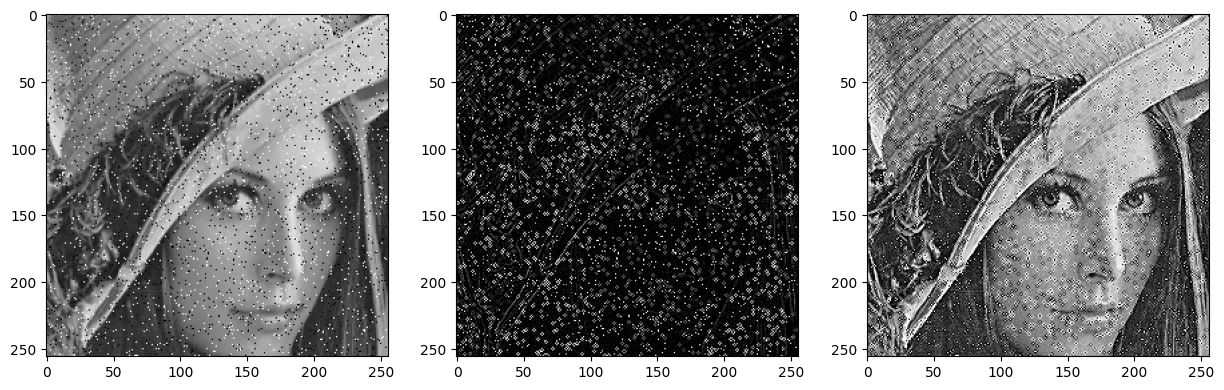

In [2]:
import numpy as np
import PIL.Image as image
import matplotlib.pyplot as plt

img = image.open(r'I:\My Drive\9th sem\DIP\Lab\images\women.png').convert('L')
img_arr = np.array(img)
h,w = img_arr.shape
print(h,w)

fil = np.array([
    [0, 1, 0],
    [1, -4, 1],
    [0, 1, 0]
])

padd = np.pad(img_arr, pad_width = 1, mode = 'edge')


l_edge = np.zeros((h,w), dtype = np.float32)

for i in range(h):
    for j in range(w):
        region = padd[i:i+3, j: j+3]
        l_edge[i,j] = np.sum(region*fil)

l_srp = img_arr - l_edge

l_edge = np.clip(l_edge, 0, 255) . astype( np.uint8)
l_srp = np.clip(l_srp, 0, 255) . astype( np.uint8)


plt.figure(figsize =(15,8))
plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.subplot(1,3,2)
plt.imshow(l_edge, cmap='gray')
plt.subplot(1,3,3)
plt.imshow(l_srp, cmap='gray')


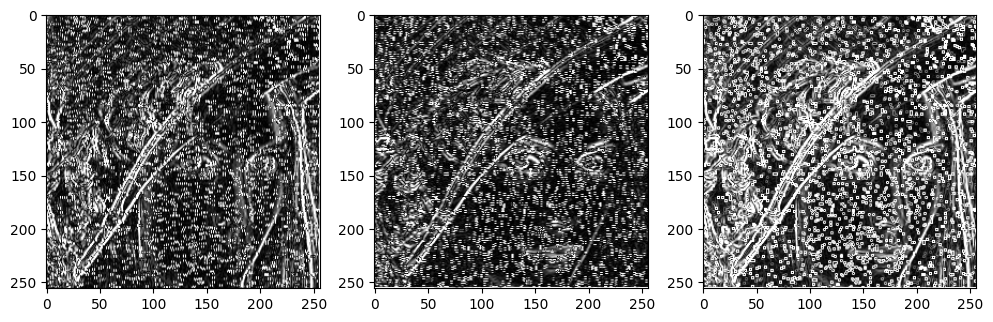

In [5]:
x_f = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

y_f = np.array([
    [-1, -2, -1],
    [0, 0, 0],
    [1, 2, 1]
])



padd = np.pad(img_arr, pad_width = 1, mode = 'constant', constant_values = 0)


gx = np.zeros((h,w), dtype = np.float32)
gy = np.zeros((h,w), dtype = np.float32)
g = np.zeros((h,w), dtype = np.float32)

for i in range(h):
    for j in range(w):
        region = padd[i:i+3, j: j+3]
        gx[i,j] = np.sum(region*x_f)
        gy[i,j] = np.sum(region*y_f)

g = np.sqrt(gx**2 + gy**2)

gx = np.clip(np.abs(gx), 0, 255) . astype( np.uint8)
gy = np.clip(np.abs(gy), 0, 255) . astype( np.uint8)
g = np.clip(g, 0, 255) . astype( np.uint8)



plt.figure(figsize =(12,4))
plt.subplot(1,3,1)
plt.imshow(gx, cmap='gray')
plt.subplot(1,3,2)
plt.imshow(gy, cmap='gray')
plt.subplot(1,3,3)
plt.imshow(g, cmap='gray')
